In [ ]:
pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("✅ All libraries loaded")

✅ All libraries loaded


In [ ]:
# Run this cell — a Choose Files button will appear
# Upload all 9 CSV files from your northstar_dataset folder

from google.colab import files
uploaded = files.upload()

print("✅ Files uploaded")

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving README.txt to README.txt
Saving vehicles.csv to vehicles.csv
✅ Files uploaded


In [ ]:
customers  = pd.read_csv("customers.csv")
orders     = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers    = pd.read_csv("drivers.csv")
vehicles   = pd.read_csv("vehicles.csv")
hubs       = pd.read_csv("hubs.csv")
complaints = pd.read_csv("complaints.csv")
incidents  = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")

print("✅ All files loaded successfully")
print(f"customers:  {len(customers)} rows")
print(f"orders:     {len(orders)} rows")
print(f"deliveries: {len(deliveries)} rows")
print(f"drivers:    {len(drivers)} rows")
print(f"vehicles:   {len(vehicles)} rows")
print(f"hubs:       {len(hubs)} rows")
print(f"complaints: {len(complaints)} rows")
print(f"incidents:  {len(incidents)} rows")
print(f"app_events: {len(app_events)} rows")

✅ All files loaded successfully
customers:  650 rows
orders:     1250 rows
deliveries: 950 rows
drivers:    170 rows
vehicles:   120 rows
hubs:       8 rows
complaints: 320 rows
incidents:  280 rows
app_events: 640 rows


Data Quality Report

In [ ]:
# Check every file for missing values
# This is your data quality assessment — screenshot this output!

print("=" * 55)
print("        DATA QUALITY REPORT — NORTHSTAR DATASET")
print("=" * 55)

datasets = {
    "customers" : customers,
    "orders"    : orders,
    "deliveries": deliveries,
    "drivers"   : drivers,
    "vehicles"  : vehicles,
    "hubs"      : hubs,
    "complaints": complaints,
    "incidents" : incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    missing      = df.isnull().sum().sum()
    missing_pct  = round(missing / (df.shape[0] * df.shape[1]) * 100, 1)
    duplicates   = df.duplicated().sum()
    print(f"\n📋 {name.upper()}")
    print(f"   Rows: {len(df)} | Columns: {len(df.columns)}")
    print(f"   Missing values: {missing} ({missing_pct}%)")
    print(f"   Duplicate rows: {duplicates}")

print("\n" + "=" * 55)

        DATA QUALITY REPORT — NORTHSTAR DATASET

📋 CUSTOMERS
   Rows: 650 | Columns: 9
   Missing values: 33 (0.6%)
   Duplicate rows: 0

📋 ORDERS
   Rows: 1250 | Columns: 11
   Missing values: 25 (0.2%)
   Duplicate rows: 0

📋 DELIVERIES
   Rows: 950 | Columns: 13
   Missing values: 33 (0.3%)
   Duplicate rows: 0

📋 DRIVERS
   Rows: 170 | Columns: 8
   Missing values: 7 (0.5%)
   Duplicate rows: 0

📋 VEHICLES
   Rows: 120 | Columns: 8
   Missing values: 4 (0.4%)
   Duplicate rows: 0

📋 HUBS
   Rows: 8 | Columns: 5
   Missing values: 0 (0.0%)
   Duplicate rows: 0

📋 COMPLAINTS
   Rows: 320 | Columns: 10
   Missing values: 16 (0.5%)
   Duplicate rows: 0

📋 INCIDENTS
   Rows: 280 | Columns: 7
   Missing values: 17 (0.9%)
   Duplicate rows: 0

📋 APP_EVENTS
   Rows: 640 | Columns: 10
   Missing values: 144 (2.2%)
   Duplicate rows: 0



Show Missing Values Detail

In [ ]:
# Show exactly which columns have missing values in each file
# Screenshot this output for your report

print("=== Missing Values Per Column ===\n")

for name, df in datasets.items():
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]
    if len(missing_cols) > 0:
        print(f"\n{name}:")
        for col, count in missing_cols.items():
            pct = round(count / len(df) * 100, 1)
            print(f"   {col}: {count} missing ({pct}%)")

=== Missing Values Per Column ===


customers:
   loyalty_score: 20 missing (3.1%)
   preferred_channel: 13 missing (2.0%)

orders:
   booking_channel: 25 missing (2.0%)

deliveries:
   delivery_completed_at: 19 missing (2.0%)
   customer_rating_post_delivery: 14 missing (1.5%)

drivers:
   training_score: 7 missing (4.1%)

vehicles:
   battery_health_pct: 4 missing (3.3%)

complaints:
   compensation_amount: 16 missing (5.0%)

incidents:
   resolved_hours: 17 missing (6.1%)

app_events:
   order_id: 144 missing (22.5%)


Clean the Data

In [ ]:
# Fix inconsistent zone names (north / NORTH / North → all become NORTH)
# Parse date columns so we can do time calculations

def clean_zone(series):
    return series.astype(str).str.strip().str.upper()

# Clean zone columns
customers["home_zone"]     = clean_zone(customers["home_zone"])
orders["pickup_zone"]      = clean_zone(orders["pickup_zone"])
orders["dropoff_zone"]     = clean_zone(orders["dropoff_zone"])
drivers["base_zone"]       = clean_zone(drivers["base_zone"])
vehicles["assigned_zone"]  = clean_zone(vehicles["assigned_zone"])
hubs["zone"]               = clean_zone(hubs["zone"])
app_events["zone_context"] = clean_zone(app_events["zone_context"])

# Fix CTR abbreviation to CENTRAL
app_events["zone_context"] = app_events["zone_context"].replace("CTR", "CENTRAL")

# Parse date columns
deliveries["dispatch_time"]          = pd.to_datetime(deliveries["dispatch_time"],          errors="coerce")
deliveries["delivery_completed_at"]  = pd.to_datetime(deliveries["delivery_completed_at"],  errors="coerce")
complaints["created_at"]             = pd.to_datetime(complaints["created_at"],             errors="coerce")
orders["order_created_at"]           = pd.to_datetime(orders["order_created_at"],           errors="coerce")

# Clean status columns
deliveries["delivery_status"] = deliveries["delivery_status"].str.strip()
complaints["severity"]        = complaints["severity"].str.strip()
complaints["status"]          = complaints["status"].str.strip()

print("✅ Data cleaning complete")
print("\nUnique delivery statuses:", deliveries["delivery_status"].unique())
print("Unique complaint severities:", complaints["severity"].unique())

✅ Data cleaning complete

Unique delivery statuses: ['Failed' 'OnTime' 'Delayed']
Unique complaint severities: ['High' 'Medium' 'Low']


Feature Engineering

In [ ]:
# Create NEW columns that don't exist in the raw data
# These help us do deeper analysis

# Feature 1: How long each delivery actually took (in hours)
deliveries["duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# Feature 2: Cost per km (efficiency measure)
deliveries["cost_per_km"] = np.where(
    deliveries["route_distance_km"] > 0,
    deliveries["fuel_or_charge_cost"] / deliveries["route_distance_km"],
    np.nan
)

# Feature 3: Whether the delivery was late (boolean)
deliveries["is_failed"] = (deliveries["delivery_status"] == "Failed").astype(int)

# Feature 4: Complaint resolution speed category
def categorise_resolution(days):
    if pd.isna(days):
        return "Unknown"
    elif days <= 2:
        return "Fast (0-2 days)"
    elif days <= 7:
        return "Normal (3-7 days)"
    else:
        return "Slow (8+ days)"

complaints["resolution_speed"] = complaints["resolution_days"].apply(categorise_resolution)

print("✅ Feature engineering complete")
print("\nNew columns added to deliveries:")
print(deliveries[["delivery_id", "duration_hours", "cost_per_km", "is_failed"]].head(10))
print("\nResolution speed categories:")
print(complaints["resolution_speed"].value_counts())

✅ Feature engineering complete

New columns added to deliveries:
  delivery_id  duration_hours  cost_per_km  is_failed
0     DL00001       22.149973     0.698146          1
1     DL00002       -1.100000     1.296905          0
2     DL00003        1.108991     1.074495          0
3     DL00004       23.985584     0.829476          0
4     DL00005        4.042814     0.634986          0
5     DL00006       28.531218     0.692197          0
6     DL00007       33.969742     0.540954          0
7     DL00008        1.805981     1.628492          0
8     DL00009        3.764631     0.392245          0
9     DL00010        6.108098     0.945178          1

Resolution speed categories:
resolution_speed
Slow (8+ days)       153
Normal (3-7 days)    112
Fast (0-2 days)       55
Name: count, dtype: int64


Analysis 1: Cost by Service Type

In [ ]:
# Merge orders with deliveries to combine revenue and cost data
merged = deliveries.merge(
    orders[["order_id", "service_type", "order_value", "pickup_zone"]],
    on="order_id",
    how="left"
)

cost_by_service = (
    merged.groupby("service_type")
    .agg(
        total_orders      = ("order_id",           "count"),
        avg_order_value   = ("order_value",         "mean"),
        avg_delivery_cost = ("fuel_or_charge_cost", "mean"),
        avg_cost_per_km   = ("cost_per_km",         "mean"),
        avg_duration_hrs  = ("duration_hours",      "mean"),
        failure_count     = ("is_failed",            "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_cost_per_km", ascending=False)
)

cost_by_service["gross_margin"] = (
    cost_by_service["avg_order_value"] - cost_by_service["avg_delivery_cost"]
).round(2)

print("=== Cost and Profitability by Service Type ===\n")
print(cost_by_service.to_string(index=False))

=== Cost and Profitability by Service Type ===

service_type  total_orders  avg_order_value  avg_delivery_cost  avg_cost_per_km  avg_duration_hrs  failure_count  gross_margin
     Medical           108            86.53              12.77             1.41              9.98             16         73.76
      Parcel           230            90.15              13.08             1.29              9.72             25         77.07
    Business           126            97.45              13.14             1.24              9.17             25         84.31
      Retail           224            86.81              12.97             1.23              9.86             28         73.84
   Passenger           262            97.19              12.40             1.21              9.13             38         84.79


Chart 1: Cost Per KM by Service Type

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

colours = ["#C0392B" if x == cost_by_service["avg_cost_per_km"].max()
           else "#2E75B6" for x in cost_by_service["avg_cost_per_km"]]

bars = ax.bar(cost_by_service["service_type"],
              cost_by_service["avg_cost_per_km"],
              color=colours, width=0.55, edgecolor="white")

# Add value labels on top of each bar
for bar, val in zip(bars, cost_by_service["avg_cost_per_km"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"£{val:.2f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Average Cost Per KM by Service Type",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Service Type", fontsize=12)
ax.set_ylabel("Avg Cost Per KM (£)", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, cost_by_service["avg_cost_per_km"].max() * 1.2)

plt.tight_layout()
plt.savefig("chart1_cost_per_km.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

Chart 2: Gross Margin by Service Type

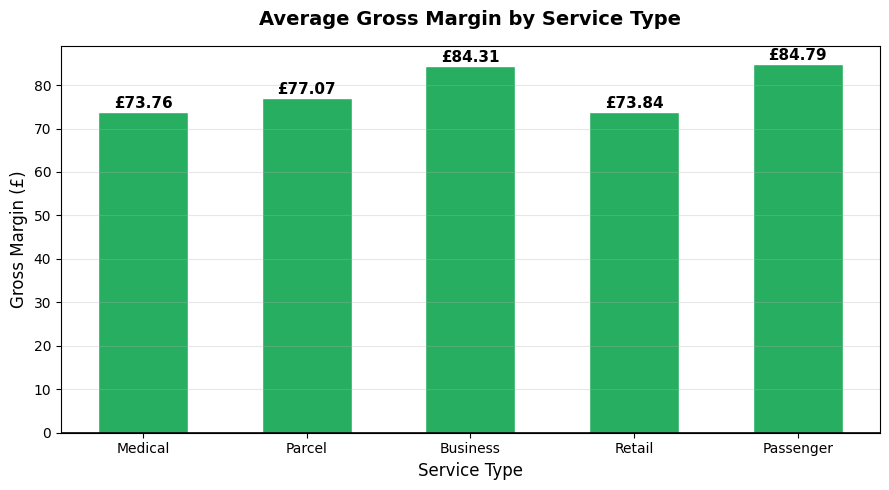

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

colours2 = ["#27AE60" if x >= 0 else "#C0392B"
            for x in cost_by_service["gross_margin"]]

bars = ax.bar(cost_by_service["service_type"],
              cost_by_service["gross_margin"],
              color=colours2, width=0.55, edgecolor="white")

for bar, val in zip(bars, cost_by_service["gross_margin"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"£{val:.2f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(y=0, color="black", linewidth=1.2)
ax.set_title("Average Gross Margin by Service Type",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Service Type", fontsize=12)
ax.set_ylabel("Gross Margin (£)", fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("chart2_gross_margin.png", dpi=150, bbox_inches="tight")
plt.show()

Analysis 2: Complaint Resolution Heatmap

=== Avg Resolution Days: Severity vs Channel ===

channel    App  Chatbot  Email  Phone
severity                             
High      14.6     11.5   12.0   14.0
Low        6.5      6.0    6.6    7.4
Medium     6.8      6.6    4.9    5.9


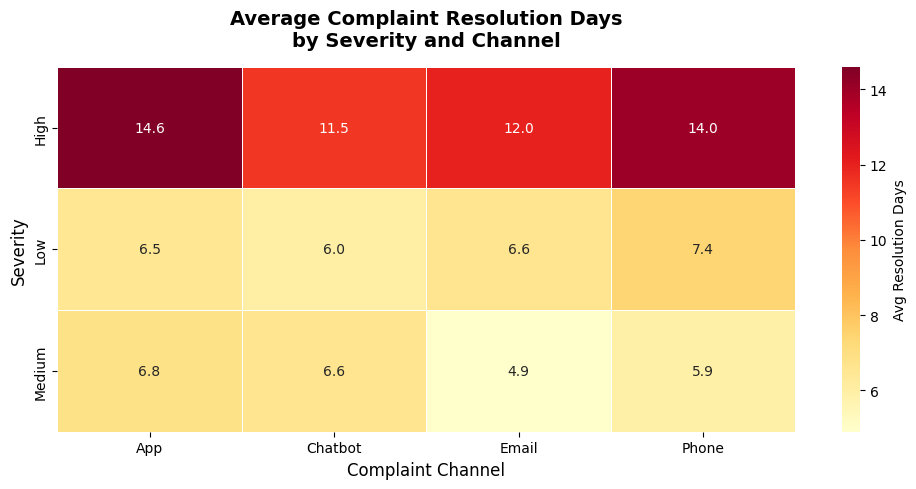

In [ ]:
# Pivot table: average resolution days by severity and channel
resolution_pivot = complaints.pivot_table(
    values  = "resolution_days",
    index   = "severity",
    columns = "channel",
    aggfunc = "mean"
).round(1)

print("=== Avg Resolution Days: Severity vs Channel ===\n")
print(resolution_pivot)

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    resolution_pivot,
    annot      = True,
    fmt        = ".1f",
    cmap       = "YlOrRd",
    linewidths = 0.5,
    linecolor  = "white",
    ax         = ax,
    cbar_kws   = {"label": "Avg Resolution Days"}
)

ax.set_title("Average Complaint Resolution Days\nby Severity and Channel",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Complaint Channel", fontsize=12)
ax.set_ylabel("Severity", fontsize=12)

plt.tight_layout()
plt.savefig("chart3_resolution_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Analysis 3: Delivery Status Breakdown

=== Overall Delivery Status Breakdown ===

 status  count  percentage
 OnTime    616        64.8
Delayed    202        21.3
 Failed    132        13.9


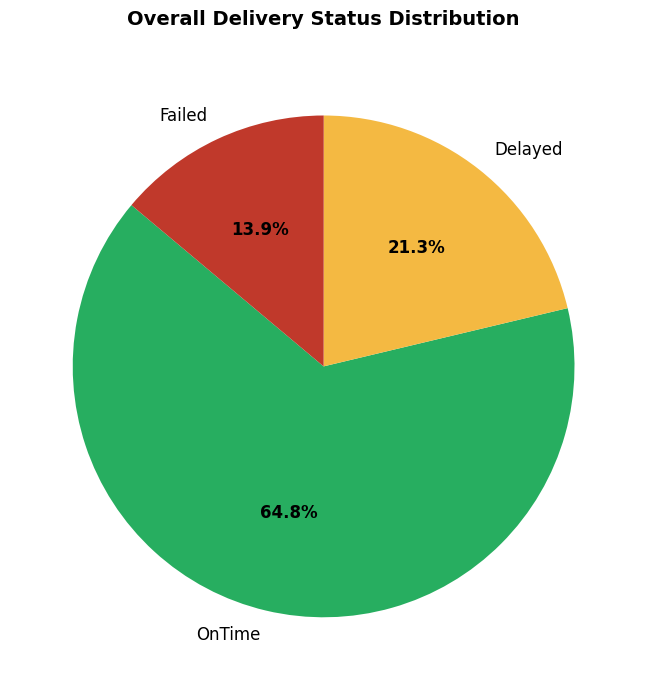

In [ ]:
# Overall delivery performance counts and percentages
status_counts = (
    deliveries["delivery_status"]
    .value_counts()
    .reset_index()
)
status_counts.columns = ["status", "count"]
status_counts["percentage"] = (
    status_counts["count"] / len(deliveries) * 100
).round(1)

print("=== Overall Delivery Status Breakdown ===\n")
print(status_counts.to_string(index=False))

# Pie chart
colours_pie = {"OnTime": "#27AE60", "Delayed": "#F4B942", "Failed": "#C0392B"}
colour_list = [colours_pie.get(s, "#95A5A6") for s in status_counts["status"]]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    status_counts["count"],
    labels     = status_counts["status"],
    colors     = colour_list,
    autopct    = "%1.1f%%",
    startangle = 140,
    textprops  = {"fontsize": 12}
)
for autotext in autotexts:
    autotext.set_fontweight("bold")

ax.set_title("Overall Delivery Status Distribution",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("chart4_delivery_status.png", dpi=150, bbox_inches="tight")
plt.show()

Analysis 4: Vehicle Type Performance

In [ ]:
# Join vehicles with deliveries to see which vehicle types perform best
vehicle_analysis = deliveries.merge(
    vehicles[["vehicle_id", "vehicle_type", "battery_health_pct", "maintenance_status"]],
    on="vehicle_id", how="left"
)

vehicle_summary = (
    vehicle_analysis.groupby("vehicle_type")
    .agg(
        total_deliveries  = ("delivery_id",         "count"),
        avg_cost_per_km   = ("cost_per_km",          "mean"),
        avg_duration_hrs  = ("duration_hours",       "mean"),
        failure_rate      = ("is_failed",             "mean"),
        avg_battery       = ("battery_health_pct",   "mean")
    )
    .round(2)
    .reset_index()
)

vehicle_summary["failure_rate_pct"] = (vehicle_summary["failure_rate"] * 100).round(1)

print("=== Vehicle Type Performance Summary ===\n")
print(vehicle_summary.drop(columns="failure_rate").to_string(index=False))

=== Vehicle Type Performance Summary ===

vehicle_type  total_deliveries  avg_cost_per_km  avg_duration_hrs  avg_battery  failure_rate_pct
    CargoVan               223             1.23              9.54        72.08              17.0
      Diesel               144             1.45             10.18        71.21              18.0
          EV               339             1.20              9.23        82.05               9.0
      Hybrid               244             1.26              9.62        77.99              16.0


Chart: Vehicle Performance

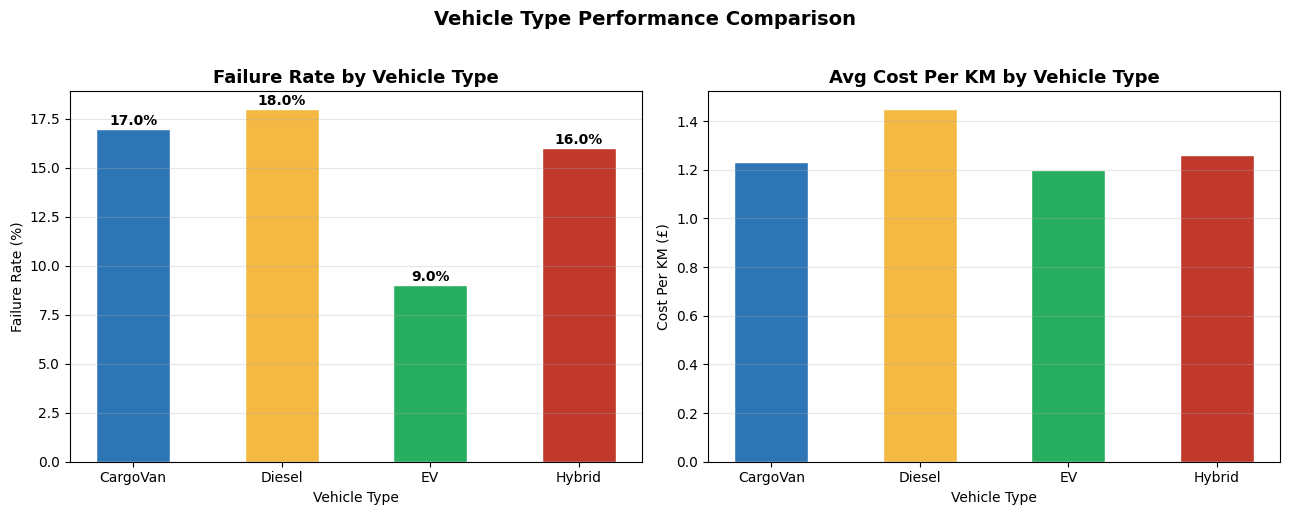

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left chart: failure rate by vehicle type
axes[0].bar(vehicle_summary["vehicle_type"],
            vehicle_summary["failure_rate_pct"],
            color=["#2E75B6", "#F4B942", "#27AE60", "#C0392B"],
            edgecolor="white", width=0.5)
axes[0].set_title("Failure Rate by Vehicle Type", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Vehicle Type")
axes[0].set_ylabel("Failure Rate (%)")
axes[0].grid(axis="y", alpha=0.3)

for i, (vtype, rate) in enumerate(
        zip(vehicle_summary["vehicle_type"], vehicle_summary["failure_rate_pct"])):
    axes[0].text(i, rate + 0.2, f"{rate}%",
                 ha="center", fontsize=10, fontweight="bold")

# Right chart: avg cost per km by vehicle type
axes[1].bar(vehicle_summary["vehicle_type"],
            vehicle_summary["avg_cost_per_km"],
            color=["#2E75B6", "#F4B942", "#27AE60", "#C0392B"],
            edgecolor="white", width=0.5)
axes[1].set_title("Avg Cost Per KM by Vehicle Type", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Vehicle Type")
axes[1].set_ylabel("Cost Per KM (£)")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Vehicle Type Performance Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart5_vehicle_performance.png", dpi=150, bbox_inches="tight")
plt.show()

Final Summary

In [ ]:
print("=" * 55)
print("     STEP 5 — PYTHON ANALYSIS COMPLETE")
print("=" * 55)

print(f"\n📊 Dataset Overview:")
print(f"   Total deliveries analysed : {len(deliveries)}")
print(f"   Total complaints          : {len(complaints)}")
print(f"   Total customers           : {len(customers)}")
print(f"   Total drivers             : {len(drivers)}")

print(f"\n💰 Financial Findings:")
print(f"   Highest margin service    : {cost_by_service.iloc[-1]['service_type']}")
print(f"   Lowest margin service     : {cost_by_service.iloc[0]['service_type']}")

print(f"\n🚚 Delivery Performance:")
print(f"   Overall failure rate      : {deliveries['is_failed'].mean()*100:.1f}%")
print(f"   Avg delivery duration     : {deliveries['duration_hours'].mean():.1f} hours")
print(f"   Avg cost per km           : £{deliveries['cost_per_km'].mean():.2f}")

print(f"\n📋 Complaints:")
print(f"   High severity             : {(complaints['severity']=='High').sum()}")
print(f"   Still open                : {(complaints['status']=='Open').sum()}")
print(f"   Avg resolution days       : {complaints['resolution_days'].mean():.1f}")

print("\n✅ All Python analysis complete!")

     STEP 5 — PYTHON ANALYSIS COMPLETE

📊 Dataset Overview:
   Total deliveries analysed : 950
   Total complaints          : 320
   Total customers           : 650
   Total drivers             : 170

💰 Financial Findings:
   Highest margin service    : Passenger
   Lowest margin service     : Medical

🚚 Delivery Performance:
   Overall failure rate      : 13.9%
   Avg delivery duration     : 9.5 hours
   Avg cost per km           : £1.26

📋 Complaints:
   High severity             : 77
   Still open                : 56
   Avg resolution days       : 7.9

✅ All Python analysis complete!
